## Neighbourhood Analysis 

In this notebook, I create multiple binary raster layers which represent the different rings around the selected cell. I can then use these files to calculate the mean value of change in PM2.5 for each ring.  


In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
from scipy import ndimage
import rasterio
from rasterio import features
from rasterio.plot import show
from rasterio import plot
import time
import seaborn as sns
import matplotlib.pyplot as plt

### Input data

In [3]:
# Read in the randomly selected points
points_vect = gpd.read_file("points.gpkg")

In [4]:
# Split between 50% tree and 100% tree
points_50  = points_vect.loc[points_vect['Category'] == 50]
points_100 = points_vect.loc[points_vect['Category'] == 100]

In [5]:
# Read in raster with the change in PM2.5 - this is BD domain and is used as a reference raster
rast_PM25_diff_BD = rasterio.open("pm_diff.tif")
rast_forest_area_BD = rasterio.open("forest_area.tif") 
rast_pm25_base_BD   = rasterio.open("pm_base.tif")

In [6]:
# Read in raster as numpy array
rast_PM25_diff_BD_np = rast_PM25_diff_BD.read(1)
rast_forest_area_BD_np = rast_forest_area_BD.read(1)
rast_pm25_base_BD_np = rast_pm25_base_BD.read(1)

### Function - Generate Rings

In [2]:
def generate_rings(input_rast):
    """
    This function creates four binary numpy arrays that include:
    - The selected/centre cell
    - The first outer ring
    - The second outer ring
    - The third outer ring
    """

    ### Centre cell 
    # Calculate the distance from all cells to nearest non-zero value 
    dist_to_cell_one = ndimage.distance_transform_edt(np.logical_not(input_rast), return_indices=False)
    # Create the binary array where selected cells are changed to a value of 1
    centre_cell = np.where(dist_to_cell_one == 0, 1, 0)

    ### Ring one
    # Create numpy array for the firsst outer ring. The first outer ring includes all adjacent cells (dist=1) and diagonal cells (dist=1.41...)
    ring_one = np.where((dist_to_cell_one > 0) & (dist_to_cell_one < 1.5), 1, 0)

    ### Ring two
    # First, we need to re-calculate the distance to non-zero values but using the ring_one variable
    dist_to_cell_two = ndimage.distance_transform_edt(np.logical_not(ring_one), return_indices=False)
    # The second ring includes the cells which are adjacent and diagonal to the first ring, except for the centre cell
    ring_two = np.where((dist_to_cell_two > 0)&(dist_to_cell_two<1.5)&(centre_cell != 1), 1, 0)

    ### Ring three
    # To get the third ring, we need to repreat the process of calculating distance and selecting all adjacent and diagonal cells (which have not already been used)
    dist_to_cell_three = ndimage.distance_transform_edt(np.logical_not(ring_two), return_indices=False)
    ring_three = np.where((dist_to_cell_three > 0)&(dist_to_cell_three<1.5)&(centre_cell != 1)&(ring_one != 1), 1, 0)

    ### Return the four vars 
    return centre_cell, ring_one, ring_two, ring_three

### Visualise centre cells and surrounding rings

In [15]:
# Get list of geometries from vector layer
point_geoms = [geom for geom in points_vect.geometry]
# Rasterise the selected central point - using pm25_diff_rast_BD as a reference raster for the extent, resolution, shape, etc.
point_raster = features.rasterize(point_geoms, out_shape=rast_PM25_diff_BD.shape, transform=rast_PM25_diff_BD.transform, fill=0)
# Generate the central cell and all surrounding rings using the `generate_rings` function created above
c_cell, r1, r2, r3 = generate_rings(point_raster)

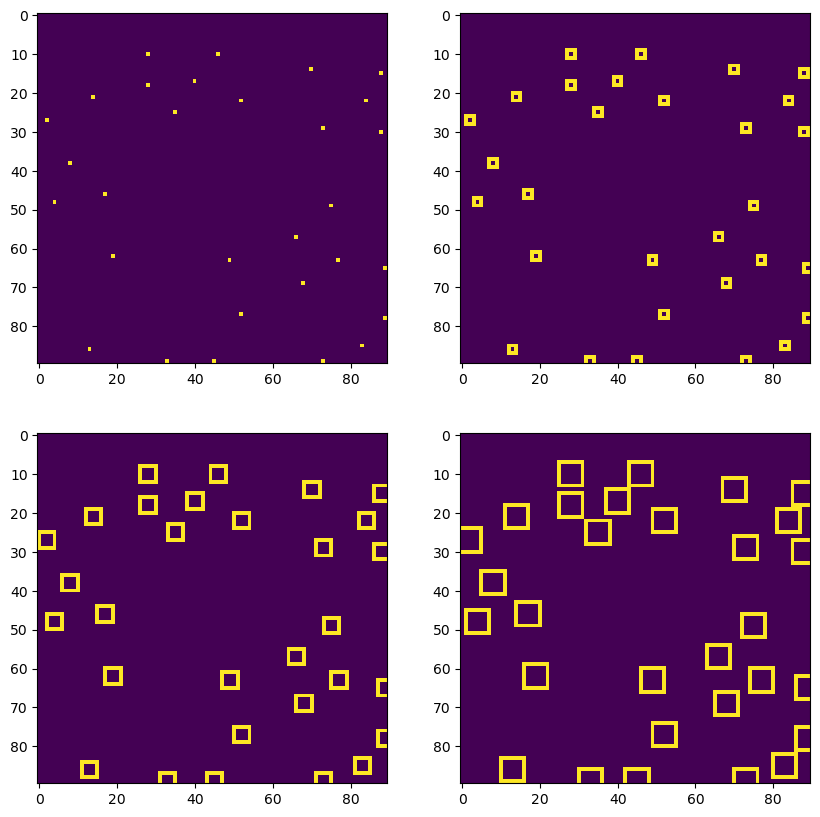

In [27]:
# Create a figure and axes
f, ax = plt.subplots(2, 2, figsize=(10,10))

ax[0, 0].imshow(c_cell)
ax[0, 1].imshow(r1)
ax[1, 0].imshow(r2)
ax[1, 1].imshow(r3);

### Function - Extract Results

In [7]:
# Get list of geometries from vector layer
geom_50 = [geom for geom in points_50.geometry]
geom_100 = [geom for geom in points_100.geometry]
geom_list = [geom_50, geom_100]

In [10]:
def get_ring_vals_with_multiple_rast(list_of_df):
    """
    Gets values from the input raster for each point and each ring
    from each dataframe.
    """

    # Creae an empty dataframe - you will append data to this dataframe each loop 
    df_master = pd.DataFrame()
    # Initialise the ring_id
    ring_id = 0

    # For each set of points
    for i in range(len(list_of_df)):
        # For each point within each set 
        for j in range(len(list_of_df[i])):
            # Initialise the tree percentage variable
            tree_area_perc = 50
            # Select a central point
            target_point = list_of_df[i][j:j+1] 
            # Rasterise the selected central point - using pm25_diff_rast_BD as a reference raster for the extent, resolution, shape, etc.
            point_raster = features.rasterize(target_point, out_shape=rast_PM25_diff_BD.shape, transform=rast_PM25_diff_BD.transform, fill=0)
            # Generate the central cell and all surrounding rings using the `generate_rings` function created above
            c_cell, r1, r2, r3 = generate_rings(point_raster)
            
            ######################
            ### Extract values ###
            ######################
            # Extract values for PM2.5 (difference and base), plus the original frac of trees, where c_cell/r1/r2/r3 is equal to one. Make the rest NA 
            
            # Central cell
            results_c_cell_pm_diff   = np.where(c_cell == 1, rast_PM25_diff_BD_np,   np.nan)
            results_c_cell_pm_base   = np.where(c_cell == 1, rast_pm25_base_BD_np,   np.nan)
            results_c_cell_area_tree = np.where(c_cell == 1, rast_forest_area_BD_np, np.nan)

            # First ring
            results_r1_pm_diff   = np.where(r1 == 1, rast_PM25_diff_BD_np,   np.nan)
            results_r1_pm_base   = np.where(r1 == 1, rast_pm25_base_BD_np,   np.nan)
            results_r1_area_tree = np.where(r1 == 1, rast_forest_area_BD_np, np.nan)

            # Second ring
            results_r2_pm_diff   = np.where(r2 == 1, rast_PM25_diff_BD_np,   np.nan)
            results_r2_pm_base   = np.where(r2 == 1, rast_pm25_base_BD_np,   np.nan)
            results_r2_area_tree = np.where(r2 == 1, rast_forest_area_BD_np, np.nan)

            # Third ring
            results_r3_pm_diff   = np.where(r3 == 1, rast_PM25_diff_BD_np,   np.nan)
            results_r3_pm_base   = np.where(r3 == 1, rast_pm25_base_BD_np,   np.nan)
            results_r3_area_tree = np.where(r3 == 1, rast_forest_area_BD_np, np.nan)
            
            ############################
            ### Convert to Pandas df ###
            ############################
            # Transfer all non-na values to a Pandas dataframe

            # Pandas df for central cell value
            df_c_cell = pd.DataFrame(results_c_cell_pm_diff[~np.isnan(results_c_cell_pm_diff)], columns=['pm_25_diff'])
            df_c_cell['pm_base'] = results_c_cell_pm_base[~np.isnan(results_c_cell_pm_base)]
            df_c_cell['area_forest'] = results_c_cell_area_tree[~np.isnan(results_c_cell_area_tree)]
            df_c_cell['ring'] = 'centre'
            df_c_cell['tree_perc'] = (i+1)*tree_area_perc
            df_c_cell['ring_id'] = ring_id
            
            # Pandas df for first ring values
            df_r1 = pd.DataFrame(results_r1_pm_diff[~np.isnan(results_r1_pm_diff)], columns=['pm_25_diff'])
            df_r1['pm_base'] = results_r1_pm_base[~np.isnan(results_r1_pm_base)]
            df_r1['area_forest'] = results_r1_area_tree[~np.isnan(results_r1_area_tree)]
            df_r1['ring'] = 'r1'
            df_r1['tree_perc'] = (i+1)*tree_area_perc
            df_r1['ring_id'] = ring_id

            # Pandas df for second ring values
            df_r2 = pd.DataFrame(results_r2_pm_diff[~np.isnan(results_r2_pm_diff)], columns=['pm_25_diff'])
            df_r2['pm_base'] = results_r2_pm_base[~np.isnan(results_r2_pm_base)]
            df_r2['area_forest'] = results_r2_area_tree[~np.isnan(results_r2_area_tree)]
            df_r2['ring'] = 'r2'
            df_r2['tree_perc'] = (i+1)*tree_area_perc
            df_r2['ring_id'] = ring_id

            # Pandas df for third ring values
            df_r3 = pd.DataFrame(results_r3_pm_diff[~np.isnan(results_r3_pm_diff)], columns=['pm_25_diff'])
            df_r3['pm_base'] = results_r3_pm_base[~np.isnan(results_r3_pm_base)]
            df_r3['area_forest'] = results_r3_area_tree[~np.isnan(results_r3_area_tree)]
            df_r3['ring'] = 'r3'
            df_r3['tree_perc'] = (i+1)*tree_area_perc
            df_r3['ring_id'] = ring_id

            # Increase the ring_id value by 1 for each loop
            ring_id += 1
            
            # Concatenate all of the values (central cell and all outer rings into a single dataframe)
            df_results = pd.concat([df_c_cell, df_r1, df_r2, df_r3])

            ###########################
            ### Append to master df ###
            ###########################
            # Append this concatenated dataframe to the master copy
            df_master = pd.concat([df_master, df_results])

    # Return the master dataframe
    return df_master

In [11]:
%%time
results_from_function = get_ring_vals_with_multiple_rast(geom_list)

CPU times: total: 219 ms
Wall time: 226 ms
